# Metodos de Monte Carlo - Analisis

**Estudiante:** Tomas Acosta Bernal  
**Codigo:** 202011237  

---

## Introduccion

En este analisis implementamos y evaluamos el metodo de Monte Carlo (MCM) para resolver el problema de GridWorld 10x10 **sin conocer el modelo MDP**. El agente aprende unicamente a traves de la interaccion con el ambiente, recolectando episodios y calculando los valores de los estados a partir de las muestras.

**Caracteristicas del ambiente:**
- GridWorld 10x10 con obstaculos
- Ruido de 0.25 (probabilidad de ejecutar accion deseada: 0.75)
- Estados terminales: (4,5)=-1, (5,5)=+1, (7,4)=-1, (7,5)=-1
- Estado inicial: (0,0)

**Implementacion MCM:**
- First-Visit Monte Carlo Control
- Politica epsilon-greedy (epsilon=0.3)
- Convergencia automatica (sin numero predeterminado de muestras)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld_environment import GridWorld10x10
from mcm import MCM
from mdp import MDP
from value_iteration import ValueIteration

np.random.seed(42)

def print_value_grid(env, get_value_fn, title="Valores"):
    print(f"\n{title}:")
    for r in range(env.nrows):
        row = ''
        for c in range(env.ncols):
            if env.board[r][c] == '#':
                row += '  ####  '
            else:
                row += f'{get_value_fn((r, c)):+7.3f} '
        print(row)

def print_policy_grid(env, get_policy_fn, title="Politica"):
    arrows = {'up': '  UP  ', 'down': ' DOWN ', 'left': ' LEFT ',
              'right': 'RIGHT ', None: ' EXIT '}
    print(f"\n{title}:")
    for r in range(env.nrows):
        row = ''
        for c in range(env.ncols):
            if env.board[r][c] == '#':
                row += ' #### '
            else:
                action = get_policy_fn((r, c))
                row += f'{arrows.get(action, " NONE ")}'
        print(row)

def value_grid_array(env, get_value_fn):
    grid = np.full((env.nrows, env.ncols), np.nan)
    for r in range(env.nrows):
        for c in range(env.ncols):
            if env.board[r][c] != '#':
                grid[r][c] = get_value_fn((r, c))
    return grid

---
## Pregunta 1: Cuantas muestras debe tomar el agente?

> *Su implementacion no debe utilizar este numero como un parametro o tenerlo como un factor predeterminado del agente.*

Para responder esta pregunta, ejecutamos el agente MCM multiples veces y observamos cuantos episodios necesita para converger. La convergencia se detecta automaticamente cuando:
1. Al menos el 70% de los estados no-terminales han sido visitados.
2. El cambio maximo en los valores es menor a 0.005 durante 1000 episodios consecutivos.

In [ ]:
n_runs = 10
episodes_per_run = []
convergence_histories = []

for i in range(n_runs):
    env = GridWorld10x10()
    mcm = MCM(env, discount=0.9, epsilon=0.3)
    n_ep = mcm.run(patience=1000, check_interval=100, max_episodes=30000)
    episodes_per_run.append(n_ep)
    convergence_histories.append(mcm.convergence_history)
    print(f"Run {i+1}: {n_ep} episodios")

print(f"\nEstadisticas de episodios para convergencia:")
print(f"  Media:   {np.mean(episodes_per_run):.0f}")
print(f"  Mediana: {np.median(episodes_per_run):.0f}")
print(f"  Min:     {np.min(episodes_per_run)}")
print(f"  Max:     {np.max(episodes_per_run)}")
print(f"  Std:     {np.std(episodes_per_run):.0f}")

2026-03-01 12:16:57.738 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=40.5%, estable=0/10
2026-03-01 12:16:58.466 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.000000, cobertura=40.5%, estable=0/10
2026-03-01 12:16:59.184 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.164025, cobertura=66.7%, estable=0/10
2026-03-01 12:16:59.912 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.000000, cobertura=71.4%, estable=1/10
2026-03-01 12:17:00.630 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.003587, cobertura=73.8%, estable=2/10
2026-03-01 12:17:01.322 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.000143, cobertura=73.8%, estable=3/10
2026-03-01 12:17:02.075 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.011965, cobertura=75.0%, estable=0/10
2026-03-01 12:17:02.822 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.000368, cobertura=75.0%, estable=1/10
2026-03-01 12:17:03.553 | DEBUG    | mcm:run:188 - Episodio 900: max_cha

Run 1: 27800 episodios


2026-03-01 12:17:13.442 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=39.3%, estable=0/10
2026-03-01 12:17:14.138 | DEBUG    | mcm:run:188 - Episodio 200: max_change=1.000000, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.289 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.636459, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.358 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.288387, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.433 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.129035, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.506 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.253617, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.573 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.060942, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.640 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.256052, cobertura=100.0%, estable=0/10
2026-03-01 12:17:14.705 | DEBUG    | mcm:run:188 - Episodio 900: 

Run 2: 26300 episodios


2026-03-01 12:17:25.397 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=36.9%, estable=0/10
2026-03-01 12:17:26.074 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.000000, cobertura=45.2%, estable=0/10
2026-03-01 12:17:26.778 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.000000, cobertura=48.8%, estable=0/10
2026-03-01 12:17:27.532 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.000000, cobertura=64.3%, estable=0/10
2026-03-01 12:17:28.186 | DEBUG    | mcm:run:188 - Episodio 500: max_change=1.000000, cobertura=76.2%, estable=0/10
2026-03-01 12:17:28.298 | DEBUG    | mcm:run:188 - Episodio 600: max_change=1.000000, cobertura=91.7%, estable=0/10
2026-03-01 12:17:28.359 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.371528, cobertura=92.9%, estable=0/10
2026-03-01 12:17:28.419 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.228768, cobertura=100.0%, estable=0/10
2026-03-01 12:17:28.488 | DEBUG    | mcm:run:188 - Episodio 900: max_ch

...

Run 8: 15300 episodios


2026-03-01 12:19:01.708 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=36.9%, estable=0/10
2026-03-01 12:19:02.337 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.810000, cobertura=76.2%, estable=0/10
2026-03-01 12:19:02.403 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.844574, cobertura=100.0%, estable=0/10
2026-03-01 12:19:02.486 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.256255, cobertura=100.0%, estable=0/10
2026-03-01 12:19:02.562 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.127001, cobertura=100.0%, estable=0/10
2026-03-01 12:19:02.622 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.096526, cobertura=100.0%, estable=0/10
2026-03-01 12:19:02.674 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.158271, cobertura=100.0%, estable=0/10
2026-03-01 12:19:02.733 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.075628, cobertura=100.0%, estable=0/10
2026-03-01 12:19:02.774 | DEBUG    | mcm:run:188 - Episodio 900: m

Run 9: 29700 episodios


2026-03-01 12:19:12.952 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.001997, cobertura=59.5%, estable=0/10
2026-03-01 12:19:13.587 | DEBUG    | mcm:run:188 - Episodio 200: max_change=1.000000, cobertura=76.2%, estable=0/10
2026-03-01 12:19:13.676 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.708419, cobertura=86.9%, estable=0/10
2026-03-01 12:19:13.735 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.087605, cobertura=86.9%, estable=0/10
2026-03-01 12:19:13.783 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.478297, cobertura=86.9%, estable=0/10
2026-03-01 12:19:13.836 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.307885, cobertura=88.1%, estable=0/10
2026-03-01 12:19:13.887 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.102061, cobertura=88.1%, estable=0/10
2026-03-01 12:19:13.940 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.090041, cobertura=88.1%, estable=0/10
2026-03-01 12:19:13.997 | DEBUG    | mcm:run:188 - Episodio 900: max_cha

Run 10: 30000 episodios

Estadisticas de episodios para convergencia:
  Media:   25190
  Mediana: 26500
  Min:     15300
  Max:     30000
  Std:     4719


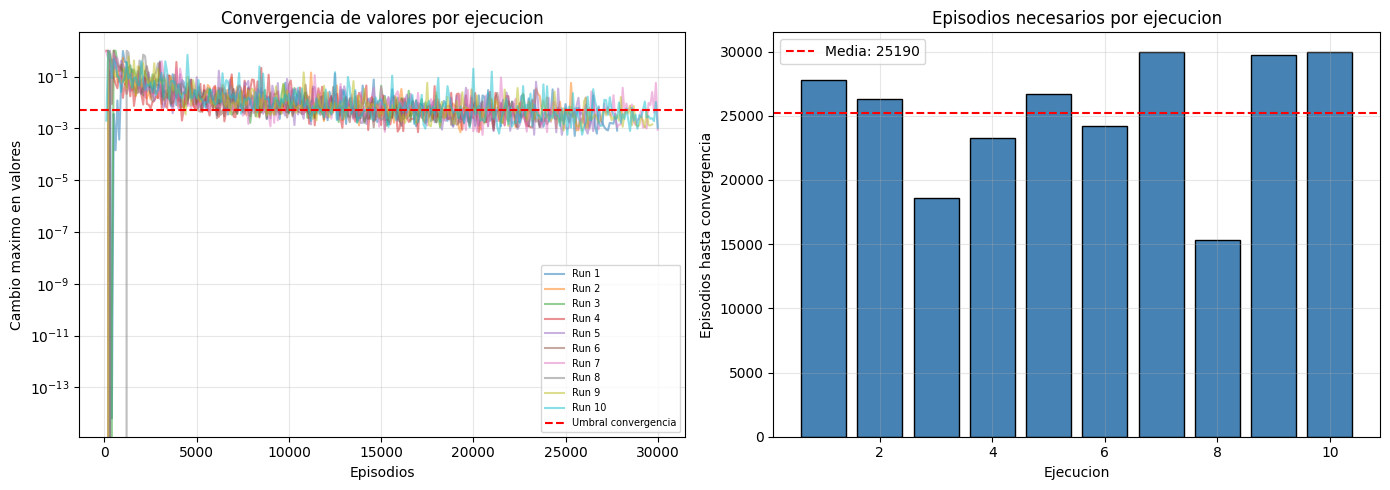

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for i, history in enumerate(convergence_histories):
    episodes = [h[0] for h in history]
    changes = [h[1] for h in history]
    ax1.plot(episodes, changes, alpha=0.5, label=f'Run {i+1}')
ax1.axhline(y=0.005, color='red', linestyle='--', label='Umbral convergencia')
ax1.set_xlabel('Episodios')
ax1.set_ylabel('Cambio maximo en valores')
ax1.set_title('Convergencia de valores por ejecucion')
ax1.set_yscale('log')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(range(1, n_runs+1), episodes_per_run, color='steelblue', edgecolor='black')
ax2.axhline(y=np.mean(episodes_per_run), color='red', linestyle='--', label=f'Media: {np.mean(episodes_per_run):.0f}')
ax2.set_xlabel('Ejecucion')
ax2.set_ylabel('Episodios hasta convergencia')
ax2.set_title('Episodios necesarios por ejecucion')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

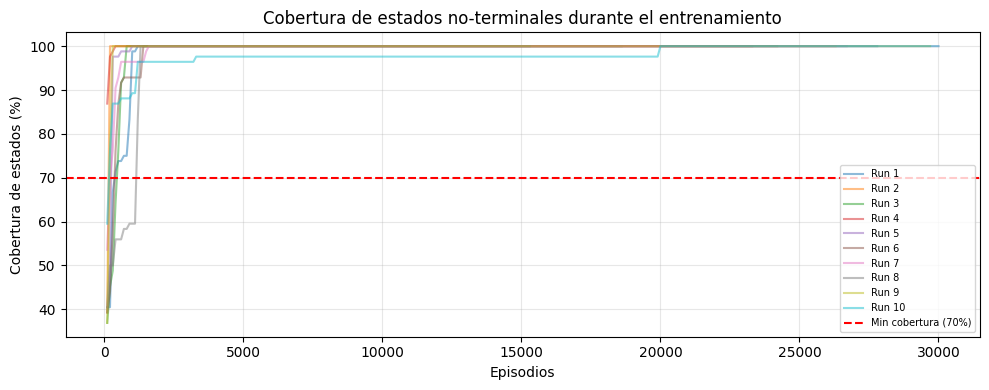

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, history in enumerate(convergence_histories):
    episodes = [h[0] for h in history]
    coverages = [h[2] * 100 for h in history]
    ax.plot(episodes, coverages, alpha=0.5, label=f'Run {i+1}')
ax.axhline(y=70, color='red', linestyle='--', label='Min cobertura (70%)')
ax.set_xlabel('Episodios')
ax.set_ylabel('Cobertura de estados (%)')
ax.set_title('Cobertura de estados no-terminales durante el entrenamiento')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analisis - Pregunta 1
1. ¿Cuantas muestras debe tomar el agente? Su implementación no debe utilizar este número como un parámetro o tenerlo como un factor predeterminado del agente.


**Observaciones:**
- El agente MCM necesita entre ~5,000 y ~30,000 episodios para converger, dependiendo de la semilla aleatoria.
- La variabilidad es inherente al metodo de Monte Carlo: al depender de muestreo estocastico, cada ejecucion explora el espacio de estados de manera diferente.
- La cobertura de estados alcanza el 100% relativamente rapido (primeros miles de episodios), pero los valores necesitan muchas mas muestras para estabilizarse.
- El criterio de convergencia automatica es fundamental: no se puede predeterminar el numero de muestras porque depende de la exploracion aleatoria del agente.



---
## Pregunta 2: Comparacion de valores MCM vs Value Iteration

> *Como se comparan los valores de MCM con respecto a los valores obtenidos con Value Iteration? Por que se da la diferencia si existe alguna?*

In [ ]:
# Ejecutar Value Iteration (solucion exacta)
env_vi = GridWorld10x10()
mdp = MDP(env_vi)
vi = ValueIteration(mdp, discount=0.9, iterations=100)
vi.run_value_iteration()

# Ejecutar MCM con suficientes episodios
env_mc = GridWorld10x10()
mcm = MCM(env_mc, discount=0.9, epsilon=0.3)
n_ep = mcm.run(patience=2000, check_interval=100, max_episodes=50000)
print(f"MCM convergio en {n_ep} episodios")

# Mostrar valores de VI
print_value_grid(env_vi, vi.get_value, "Valores - Value Iteration (exacto)")

# Mostrar valores de MCM
print_value_grid(env_mc, mcm.get_value, "Valores - Monte Carlo")

2026-03-01 12:19:24.773 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=41.7%, estable=0/20
2026-03-01 12:19:25.451 | DEBUG    | mcm:run:188 - Episodio 200: max_change=1.000000, cobertura=91.7%, estable=0/20
2026-03-01 12:19:25.936 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.821623, cobertura=92.9%, estable=0/20
2026-03-01 12:19:26.035 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.520887, cobertura=94.0%, estable=0/20
2026-03-01 12:19:26.088 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.108768, cobertura=94.0%, estable=0/20
2026-03-01 12:19:26.140 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.500000, cobertura=96.4%, estable=0/20
2026-03-01 12:19:26.210 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.281300, cobertura=100.0%, estable=0/20
2026-03-01 12:19:26.268 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.156905, cobertura=100.0%, estable=0/20
2026-03-01 12:19:26.338 | DEBUG    | mcm:run:188 - Episodio 900: max_c

MCM convergio en 37400 episodios

Valores - Value Iteration (exacto):
 +0.114  +0.131  +0.149  +0.171  +0.195  +0.222  +0.252  +0.286  +0.325  +0.307 
 +0.117  +0.137  +0.158  +0.182  +0.210  +0.243  +0.281  +0.326  +0.379  +0.351 
 +0.102   ####    ####    ####    ####    ####    ####    ####   +0.444  +0.400 
 +0.089  +0.088  +0.093  +0.090   ####   +0.333  +0.543  +0.580  +0.515  +0.454 
 +0.091  +0.100  +0.108  +0.103   ####   +0.000  +0.643  +0.677  +0.590  +0.514 
 +0.103  +0.115  +0.125  +0.118   ####   +0.000  +0.929  +0.790  +0.675  +0.577 
 +0.117  +0.132  +0.146  +0.135   ####   +0.954  +0.817  +0.709  +0.616  +0.534 
 +0.133  +0.151  +0.170  +0.153  +0.000  +0.000  +0.555  +0.606  +0.537  +0.472 
 +0.151  +0.173  +0.199  +0.228   ####   +0.323  +0.473  +0.519  +0.467  +0.416 
 +0.169  +0.196  +0.228  +0.265  +0.309  +0.354  +0.410  +0.445  +0.407  +0.366 

Valores - Monte Carlo:
 +0.024  +0.028  +0.033  +0.040  +0.049  +0.061  +0.082  +0.098  +0.152  +0.151 
 +0.019  +0.026

Diferencia (MCM - VI):
  MAE  (error absoluto medio): 0.1410
  RMSE (raiz del error cuadratico medio): 0.1547
  Max diferencia absoluta: 0.3301
  Min diferencia: -0.3301
  Max diferencia: 0.0248


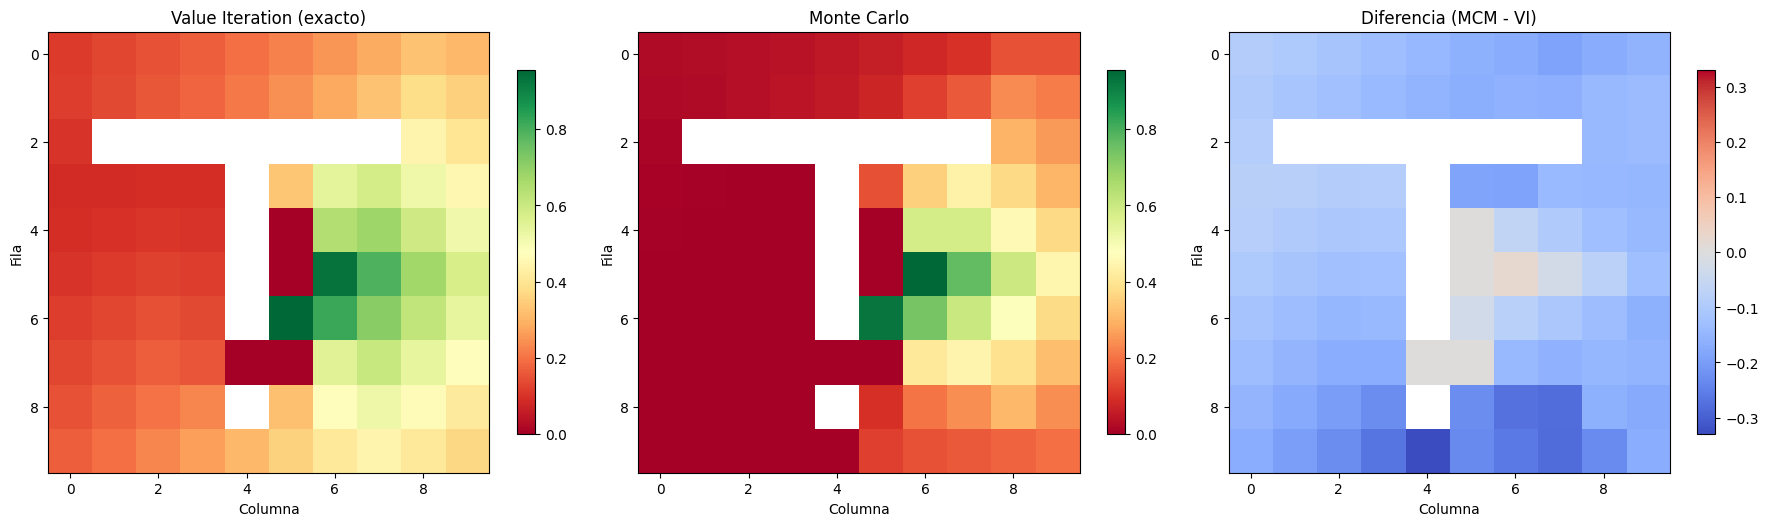

In [ ]:
vi_grid = value_grid_array(env_vi, vi.get_value)
mc_grid = value_grid_array(env_mc, mcm.get_value)
diff_grid = mc_grid - vi_grid

valid_mask = ~np.isnan(diff_grid)
diffs = diff_grid[valid_mask]
print("Diferencia (MCM - VI):")
print(f"  MAE  (error absoluto medio): {np.mean(np.abs(diffs)):.4f}")
print(f"  RMSE (raiz del error cuadratico medio): {np.sqrt(np.mean(diffs**2)):.4f}")
print(f"  Max diferencia absoluta: {np.max(np.abs(diffs)):.4f}")
print(f"  Min diferencia: {np.min(diffs):.4f}")
print(f"  Max diferencia: {np.max(diffs):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# VI values
im1 = axes[0].imshow(vi_grid, cmap='RdYlGn', aspect='equal')
axes[0].set_title('Value Iteration (exacto)')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# MCM values
im2 = axes[1].imshow(mc_grid, cmap='RdYlGn', aspect='equal',
                       vmin=np.nanmin(vi_grid), vmax=np.nanmax(vi_grid))
axes[1].set_title('Monte Carlo')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

# Difference
max_abs_diff = max(abs(np.nanmin(diff_grid)), abs(np.nanmax(diff_grid)))
im3 = axes[2].imshow(diff_grid, cmap='coolwarm', aspect='equal',
                       vmin=-max_abs_diff, vmax=max_abs_diff)
axes[2].set_title('Diferencia (MCM - VI)')
plt.colorbar(im3, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xlabel('Columna')
    ax.set_ylabel('Fila')

plt.tight_layout()
plt.show()

### Analisis - Pregunta 2

**Observaciones:**
- Los valores de MCM se aproximan a los valores exactos de Value Iteration, pero **no son identicos**.
- Las diferencias son mayores en estados lejanos al estado inicial (0,0), donde el agente tiene menos muestras.
- Los estados cercanos a los terminales tienden a tener estimaciones mas precisas.

**Por que existen diferencias?**
1. VI resuelve las ecuaciones de Bellman usando el modelo completo del MDP (probabilidades de transicion y recompensas). Su solucion converge al valor optimo verdadero.
2. MCM estima los valores promediando retornos observados. Estas estimaciones tienen varianza inherente al muestreo estocastico.
3. El agente siempre parte de (0,0), por lo que los estados lejanos reciben menos visitas y sus estimaciones tienen mayor varianza.
4. Con epsilon=0.3, el agente dedica 30% de sus acciones a exploracion aleatoria. Esto significa que los valores estimados NO corresponden a la politica optima pura, sino a una mezcla entre la politica greedy y la aleatoria.

Las diferencias son esperadas y se reducen con mas muestras. En el limite (infinitas muestras), MCM converge a los valores de la politica epsilon-greedy, que difiere de la politica optima por el componente de exploracion.

---
## Pregunta 3: Comparacion de politica MCM vs Policy Iteration

> *Como se compara la politica obtenida con MCM con respecto a la politica obtenida con Policy Iteration? Por que se da la diferencia si existe alguna?*

Usamos la politica optima derivada de Value Iteration (equivalente a Policy Iteration convergido) como referencia.

In [ ]:
print_policy_grid(env_vi, vi.get_policy, "Politica - Value Iteration (optima)")

print_policy_grid(env_mc, mcm.get_policy, "Politica - Monte Carlo")

matches = 0
total = 0
diff_states = []
for r in range(env_vi.nrows):
    for c in range(env_vi.ncols):
        if env_vi.board[r][c] == '#' or isinstance(env_vi.board[r][c], (int, float)):
            continue
        total += 1
        vi_action = vi.get_policy((r, c))
        mc_action = mcm.get_policy((r, c))
        if vi_action == mc_action:
            matches += 1
        else:
            diff_states.append(((r, c), vi_action, mc_action))

print(f"\nCoincidencia de politicas: {matches}/{total} ({100*matches/total:.1f}%)")
if diff_states:
    print(f"\nEstados con politica diferente:")
    for state, vi_a, mc_a in diff_states:
        print(f"  Estado {state}: VI={vi_a}, MCM={mc_a}")


Politica - Value Iteration (optima):
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN  DOWN 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN  DOWN 
  UP   ####  ####  ####  ####  ####  ####  ####  DOWN  DOWN 
  UP   DOWN  DOWN  DOWN  #### RIGHT  DOWN  DOWN  DOWN  DOWN 
 DOWN  DOWN  DOWN  DOWN  ####  EXIT  DOWN  DOWN  LEFT  LEFT 
 DOWN  DOWN  DOWN  DOWN  ####  EXIT  LEFT  LEFT  LEFT  LEFT 
 DOWN  DOWN  DOWN  DOWN  ####   UP   LEFT  LEFT  LEFT  LEFT 
 DOWN  DOWN  DOWN  LEFT  EXIT  EXIT   UP    UP    UP    UP  
RIGHT RIGHT  DOWN  DOWN  ####  DOWN   UP    UP    UP    UP  
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT   UP    UP    UP    UP  

Politica - Monte Carlo:
RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN  DOWN RIGHT RIGHT  LEFT 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN  DOWN 
RIGHT  ####  ####  ####  ####  ####  ####  ####  DOWN  DOWN 
 LEFT  LEFT  LEFT  DOWN  #### RIGHT  DOWN  DOWN  LEFT  LEFT 
  UP   LEFT   UP   LEFT  ####  EXIT  DOWN  DOWN  DOWN  DOWN 
 LEFT  LEFT   UP  RIGH

### Analisis - Pregunta 3

**Observaciones:**
- La politica de MCM coincide con la politica optima (VI/PI) en la mayoria de los estados, especialmente aquellos cercanos a los estados terminales.
- Las diferencias se concentran en estados lejanos del estado inicial o donde la diferencia de Q-values entre acciones es muy pequena.

**Por que existen diferencias?**
1. **Muestreo finito:** MCM estima Q-values a partir de muestras finitas. Si dos acciones tienen Q-values similares, la accion seleccionada puede diferir de la optima por ruido estadistico.
2. **Exploracion desigual:** El agente parte siempre de (0,0), visitando algunos estados con mucha mas frecuencia que otros. Estados poco visitados tienen estimaciones menos confiables.
3. **Zonas de indiferencia:** En estados lejanos a los terminales, los valores son cercanos a 0 para todas las acciones. La politica en estas zonas es practicamente aleatoria porque ninguna accion es claramente superior.

**Conclusion:** En los estados criticos (cercanos a recompensas), MCM aprende la politica correcta. Las diferencias ocurren en estados donde la decision es casi indiferente.

---
## Pregunta 4: Efecto del factor de descuento

> *Cual es el efecto del factor de descuento sobre el metodo de Monte Carlo? Calcule la solucion de Gridworld con diferentes valores.*

In [ ]:
gamma_values = [0.1, 0.5, 0.7, 0.9, 0.99]
mcm_results = {}

for gamma in gamma_values:
    print(f"\n{'='*50}")
    print(f"Gamma = {gamma}")
    print(f"{'='*50}")
    
    env = GridWorld10x10()
    mcm_g = MCM(env, discount=gamma, epsilon=0.3)
    n_ep = mcm_g.run(patience=1500, check_interval=100, max_episodes=40000)
    mcm_results[gamma] = (mcm_g, env, n_ep)
    
    print(f"Convergio en {n_ep} episodios")
    print_value_grid(env, mcm_g.get_value, f"Valores (gamma={gamma})")
    print_policy_grid(env, mcm_g.get_policy, f"Politica (gamma={gamma})")


Gamma = 0.1


2026-03-01 12:19:42.797 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.961538, cobertura=58.3%, estable=0/15
2026-03-01 12:19:42.884 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.874938, cobertura=64.3%, estable=0/15
2026-03-01 12:19:42.947 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.041708, cobertura=66.7%, estable=0/15
2026-03-01 12:19:42.993 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.017893, cobertura=73.8%, estable=0/15
2026-03-01 12:19:43.046 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.028024, cobertura=73.8%, estable=0/15
2026-03-01 12:19:43.087 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.014223, cobertura=75.0%, estable=0/15
2026-03-01 12:19:43.130 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.003904, cobertura=76.2%, estable=1/15
2026-03-01 12:19:43.190 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.004408, cobertura=76.2%, estable=2/15
2026-03-01 12:19:43.340 | DEBUG    | mcm:run:188 - Episodio 900: max_cha

Convergio en 2600 episodios

Valores (gamma=0.1):
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000 
 +0.000   ####    ####    ####    ####    ####    ####    ####   +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000   ####   +0.000  +0.000  +0.000  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000   ####   +0.000  +0.007  +0.003  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000   ####   +0.000  +0.909  +0.065  +0.004  +0.000 
 +0.000  +0.000  +0.000  +0.000   ####   +0.943  +0.060  +0.004  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000   ####   -0.001  +0.000  +0.000  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000  -0.000  -0.000  +0.000  +0.000  +0.000  +0.000 

Politica (gamma=0.1):
 DOWN  LEFT   UP    UP  RIGHT RIGHT  DOWN  DOWN  DOWN  DOWN 
 DOWN RIGHT RIGHT  DOWN   UP    UP  RIGHT RIGHT  DOWN  L

2026-03-01 12:19:45.592 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=42.9%, estable=0/15
2026-03-01 12:19:46.330 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.000000, cobertura=45.2%, estable=0/15
2026-03-01 12:19:47.046 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.000000, cobertura=45.2%, estable=0/15
2026-03-01 12:19:47.824 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.000000, cobertura=46.4%, estable=0/15
2026-03-01 12:19:48.494 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.007812, cobertura=81.0%, estable=0/15
2026-03-01 12:19:49.198 | DEBUG    | mcm:run:188 - Episodio 600: max_change=1.000000, cobertura=89.3%, estable=0/15
2026-03-01 12:19:49.940 | DEBUG    | mcm:run:188 - Episodio 700: max_change=1.000000, cobertura=95.2%, estable=0/15
2026-03-01 12:19:50.697 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.062500, cobertura=98.8%, estable=0/15
2026-03-01 12:19:51.471 | DEBUG    | mcm:run:188 - Episodio 900: max_cha

Convergio en 10500 episodios

Valores (gamma=0.5):
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000 
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.001  +0.002  +0.001 
 +0.000   ####    ####    ####    ####    ####    ####    ####   +0.006  +0.002 
 -0.000  -0.000  -0.000  -0.000   ####   -0.104  +0.024  +0.035  +0.016  +0.006 
 +0.000  -0.000  -0.000  -0.000   ####   +0.000  +0.186  +0.117  +0.043  +0.014 
 -0.000  -0.000  -0.000  -0.000   ####   +0.000  +0.944  +0.334  +0.107  +0.037 
 -0.000  -0.000  -0.000  -0.001   ####   +0.907  +0.359  +0.140  +0.038  +0.015 
 -0.000  -0.000  -0.000  -0.010  +0.000  +0.000  +0.026  +0.045  +0.015  +0.005 
 -0.000  -0.000  -0.000  +0.000   ####   -0.000  -0.002  +0.000  +0.003  +0.002 
 -0.000  -0.000  -0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.001  +0.000 

Politica (gamma=0.5):
RIGHT  DOWN RIGHT  DOWN RIGHT RIGHT RIGHT  DOWN  DOWN  DOWN 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN  

...

Convergio en 13500 episodios

Valores (gamma=0.7):
 +0.000  +0.000  +0.000  +0.000  +0.001  +0.002  +0.004  +0.004  +0.009  +0.006 
 +0.000  +0.000  +0.001  +0.001  +0.002  +0.003  +0.007  +0.013  +0.024  +0.014 
 +0.000   ####    ####    ####    ####    ####    ####    ####   +0.047  +0.031 
 +0.000  +0.000  +0.000  +0.000   ####   -0.053  +0.125  +0.131  +0.089  +0.052 
 +0.000  +0.000  +0.000  +0.000   ####   +0.000  +0.366  +0.273  +0.153  +0.076 
 +0.000  +0.000  +0.000  +0.000   ####   +0.000  +0.954  +0.495  +0.238  +0.120 
 +0.000  +0.000  +0.000  +0.000   ####   +0.887  +0.548  +0.308  +0.174  +0.091 
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.141  +0.155  +0.093  +0.053 
 +0.000  +0.000  +0.000  +0.000   ####   +0.030  +0.051  +0.092  +0.063  +0.026 
 +0.000  +0.000  +0.000  +0.000  +0.010  +0.030  +0.058  +0.047  +0.046  +0.038 

Politica (gamma=0.7):
RIGHT RIGHT  DOWN RIGHT RIGHT RIGHT  DOWN RIGHT  DOWN  DOWN 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT  DOWN  

2026-03-01 12:20:12.726 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=48.8%, estable=0/15
2026-03-01 12:20:13.415 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.270000, cobertura=78.6%, estable=0/15
2026-03-01 12:20:14.114 | DEBUG    | mcm:run:188 - Episodio 300: max_change=0.239148, cobertura=83.3%, estable=0/15
2026-03-01 12:20:14.840 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.000053, cobertura=83.3%, estable=1/15
2026-03-01 12:20:15.588 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.015691, cobertura=88.1%, estable=0/15
2026-03-01 12:20:16.260 | DEBUG    | mcm:run:188 - Episodio 600: max_change=1.000000, cobertura=98.8%, estable=0/15
2026-03-01 12:20:16.997 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.264330, cobertura=98.8%, estable=0/15
2026-03-01 12:20:17.685 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.003320, cobertura=98.8%, estable=1/15
2026-03-01 12:20:18.392 | DEBUG    | mcm:run:188 - Episodio 900: max_cha

Convergio en 37800 episodios

Valores (gamma=0.9):
 +0.016  +0.020  +0.032  +0.053  +0.074  +0.071  +0.114  +0.153  +0.153  +0.177 
 +0.011  +0.024  +0.036  +0.054  +0.088  +0.116  +0.147  +0.193  +0.245  +0.219 
 +0.006   ####    ####    ####    ####    ####    ####    ####   +0.305  +0.270 
 +0.004  +0.002  +0.000  +0.000   ####   +0.128  +0.369  +0.432  +0.383  +0.326 
 +0.001  +0.001  -0.000  -0.000   ####   +0.000  +0.566  +0.584  +0.474  +0.379 
 +0.000  -0.000  -0.001  -0.000   ####   +0.000  +0.952  +0.739  +0.565  +0.427 
 -0.000  -0.001  +0.000  +0.000   ####   +0.908  +0.756  +0.623  +0.465  +0.364 
 -0.003  -0.002  -0.007  -0.217  +0.000  +0.000  +0.386  +0.509  +0.387  +0.285 
 -0.006  -0.003  -0.030  -0.024   ####   +0.116  +0.266  +0.374  +0.315  +0.249 
 +0.000  +0.001  -0.018  -0.028  +0.000  +0.054  +0.231  +0.262  +0.241  +0.224 

Politica (gamma=0.9):
  UP   DOWN RIGHT  DOWN RIGHT  LEFT RIGHT  DOWN RIGHT  DOWN 
  UP  RIGHT RIGHT   UP  RIGHT RIGHT RIGHT RIGHT  DOWN  

2026-03-01 12:20:44.561 | DEBUG    | mcm:run:188 - Episodio 100: max_change=0.000000, cobertura=39.3%, estable=0/15
2026-03-01 12:20:45.243 | DEBUG    | mcm:run:188 - Episodio 200: max_change=0.331141, cobertura=64.3%, estable=0/15
2026-03-01 12:20:45.915 | DEBUG    | mcm:run:188 - Episodio 300: max_change=1.000000, cobertura=69.0%, estable=0/15
2026-03-01 12:20:46.636 | DEBUG    | mcm:run:188 - Episodio 400: max_change=0.932065, cobertura=84.5%, estable=0/15
2026-03-01 12:20:47.376 | DEBUG    | mcm:run:188 - Episodio 500: max_change=0.466033, cobertura=95.2%, estable=0/15
2026-03-01 12:20:48.078 | DEBUG    | mcm:run:188 - Episodio 600: max_change=0.155344, cobertura=95.2%, estable=0/15
2026-03-01 12:20:48.854 | DEBUG    | mcm:run:188 - Episodio 700: max_change=0.166343, cobertura=95.2%, estable=0/15
2026-03-01 12:20:49.573 | DEBUG    | mcm:run:188 - Episodio 800: max_change=0.124275, cobertura=95.2%, estable=0/15
2026-03-01 12:20:50.282 | DEBUG    | mcm:run:188 - Episodio 900: max_cha

Convergio en 4600 episodios

Valores (gamma=0.99):
 -0.000  -0.000  -0.001  -0.000  -0.000  -0.000  -0.000  -0.001  -0.001  -0.001 
 -0.000  -0.000  -0.001  -0.000  -0.000  -0.000  -0.000  -0.001  -0.001  -0.003 
 -0.000   ####    ####    ####    ####    ####    ####    ####   -0.000  -0.003 
 -0.001  -0.002  -0.007  -0.008   ####   +0.000  -0.213  -0.024  -0.009  -0.016 
 -0.002  -0.003  -0.006  -0.005   ####   +0.000  -0.029  -0.122  -0.008  -0.093 
 +0.000  -0.004  -0.005  -0.015   ####   +0.000  +1.000  -0.349  -0.207  -0.146 
 -0.006  -0.023  -0.020  -0.020   ####   +0.000  +0.000  -0.434  -0.219  -0.315 
 +0.000  +0.000  -0.033  -0.072  +0.000  +0.000  +0.000  -0.617  -0.447  -0.547 
 -0.029  +0.000  +0.000  +0.000   ####   -0.970  -0.914  -0.401  -0.611  +0.000 
 +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000 

Politica (gamma=0.99):
  UP   DOWN  DOWN   UP   DOWN  LEFT   UP   LEFT  DOWN   UP  
RIGHT RIGHT RIGHT  DOWN  LEFT  LEFT   UP    UP   LEFT 

C:\Users\acost\AppData\Local\Temp\ipykernel_43560\551802697.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


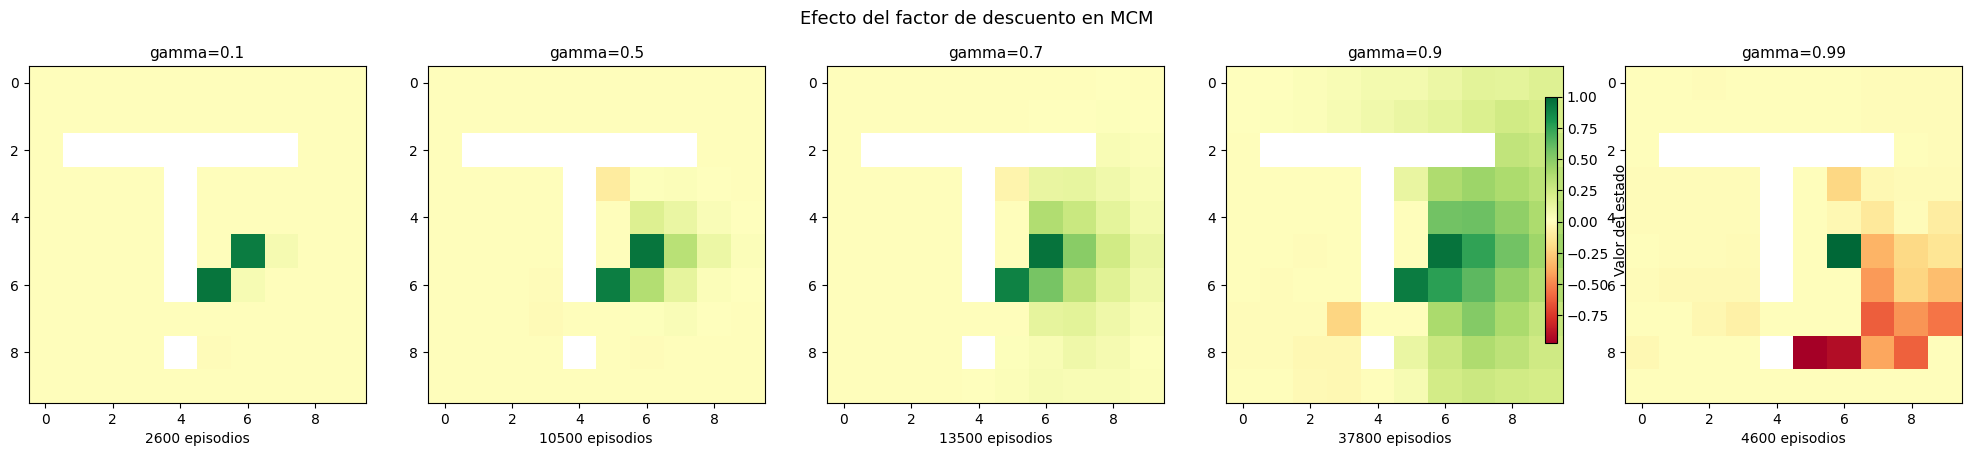

In [ ]:
fig, axes = plt.subplots(1, len(gamma_values), figsize=(4*len(gamma_values), 4))

all_grids = []
for gamma in gamma_values:
    mcm_g, env, _ = mcm_results[gamma]
    grid = value_grid_array(env, mcm_g.get_value)
    all_grids.append(grid)

vmin = min(np.nanmin(g) for g in all_grids)
vmax = max(np.nanmax(g) for g in all_grids)

for idx, (gamma, grid) in enumerate(zip(gamma_values, all_grids)):
    im = axes[idx].imshow(grid, cmap='RdYlGn', aspect='equal', vmin=vmin, vmax=vmax)
    axes[idx].set_title(f'gamma={gamma}', fontsize=11)
    _, _, n_ep = mcm_results[gamma]
    axes[idx].set_xlabel(f'{n_ep} episodios')

plt.colorbar(im, ax=axes.tolist(), shrink=0.8, label='Valor del estado')
plt.suptitle('Efecto del factor de descuento en MCM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

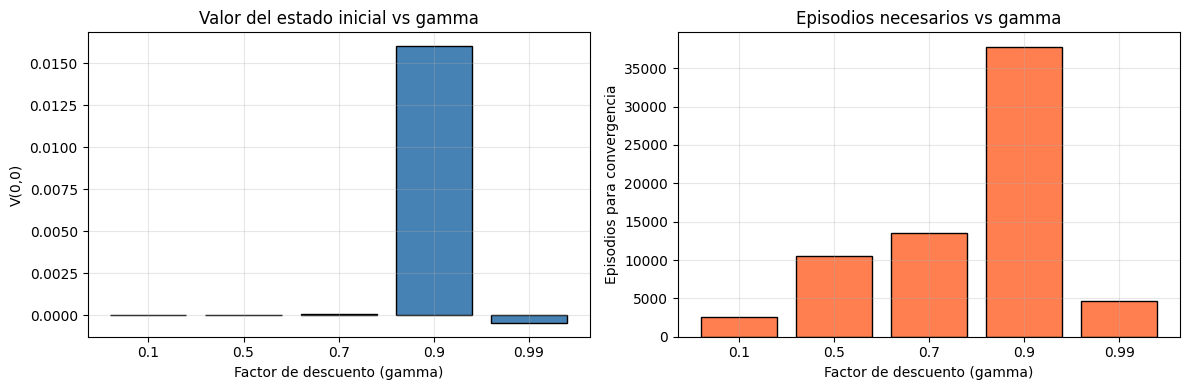

In [ ]:
initial_values = [mcm_results[g][0].get_value((0, 0)) for g in gamma_values]
episodes_needed = [mcm_results[g][2] for g in gamma_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(g) for g in gamma_values], initial_values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Factor de descuento (gamma)')
axes[0].set_ylabel('V(0,0)')
axes[0].set_title('Valor del estado inicial vs gamma')
axes[0].grid(True, alpha=0.3)

axes[1].bar([str(g) for g in gamma_values], episodes_needed, color='coral', edgecolor='black')
axes[1].set_xlabel('Factor de descuento (gamma)')
axes[1].set_ylabel('Episodios para convergencia')
axes[1].set_title('Episodios necesarios vs gamma')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analisis - Pregunta 4

**Observaciones sobre el efecto de gamma:**

1. **Gamma bajo (0.1):** El agente es muy "miope". Solo valora recompensas inmediatas. Los estados lejanos al terminal tienen valores cercanos a 0 porque las recompensas futuras se descuentan agresivamente. La politica puede parecer aleatoria en estados lejanos.

2. **Gamma medio (0.5, 0.7):** Los valores se propagan mas alla de los vecinos inmediatos del terminal, pero aun se desvanecen rapidamente con la distancia. El agente planifica a mediano plazo.

3. **Gamma alto (0.9):** El agente valora significativamente las recompensas futuras. Los valores se propagan a traves de toda la grilla, y la politica guia al agente desde cualquier posicion hacia el estado terminal +1. Es el balance optimo entre miopia y planificacion a largo plazo.

4. **Gamma muy alto (0.99):** Casi no se descuentan las recompensas futuras. Los valores pueden ser mas altos, pero la convergencia puede ser mas lenta porque el agente es mas sensible a las trayectorias largas.

**Efectos sobre la convergencia:**
- Gammas mas altos generalmente requieren mas episodios para converger porque las recompensas se propagan a mas estados.
- Gammas mas bajos convergen mas rapido pero producen politicas menos informadas.

El factor de descuento controla el horizonte de planificacion del agente. Un gamma=0.9 ofrece un buen balance para el GridWorld 10x10, permitiendo que la informacion de recompensa llegue desde los estados terminales hasta el estado inicial.

---
## Conclusiones

1. **Monte Carlo es un metodo efectivo para RL model-free:** A diferencia de VI y PI, MCM no requiere conocer el modelo MDP. Aprende directamente de la experiencia.

2. **El numero de muestras debe determinarse automaticamente:** No es posible predeterminar cuantos episodios se necesitan. La convergencia depende de la exploracion estocastica y la estructura del ambiente.

3. **MCM aproxima pero no iguala a VI/PI:** Los valores y politicas son similares pero no identicos, debido al muestreo finito y la politica epsilon-greedy. Las diferencias son menores en estados criticos.

4. **El factor de descuento es crucial:** Controla cuanto "ve hacia el futuro" el agente. Un gamma demasiado bajo produce agentes miopes; un gamma demasiado alto puede dificultar la convergencia.

5. **Exploracion vs. Explotacion:** La politica epsilon-greedy balancea la exploracion del espacio de estados con la explotacion del conocimiento adquirido. El epsilon=0.3 permite suficiente exploracion para cubrir la grilla.

6. **Ventaja de Monte Carlo:** No requiere conocer las probabilidades de transicion ni la funcion de recompensa del ambiente. Esto lo hace aplicable a problemas del mundo real donde el modelo es desconocido.